## Figure 7

Note: This notebook requires the following simulation outputs (see `simulations.md` for run commands):

- `out/fig7_st_learned/`, `out/fig7_st_random/`, `out/fig7_st_analytic/`: student-teacher task, 5 seeds each (panels b-c, e-i)
- `out/fig7_st_frequency/`: student-teacher task, 5 offline-phase frequencies x 3 seeds (panels k-m)
- `out/fig7_fmnist_learned/`, `out/fig7_fmnist_pretrained/`, `out/fig7_fmnist_random/`: Fashion-MNIST, 5 seeds each (panels n-q)
- `out/fig6_fmnist_3l/`, `out/fig6_fmnist_bp_3l/`: Figure 6 Fashion-MNIST runs, used as analytic-feedback and backprop references (panels n, o, q)
- `out/fig6_fmnist_nohl/`: Figure 6 no-hidden-layer control, dashed line in panel q (optional)

Panels b-c re-simulate one offline phase of the trained seed-1 network on CPU (a few seconds). Panels e-f rebuild the five untrained random-feedback networks for the reference line.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["JAX_PLATFORM_NAME"] = "cpu"

from collections import defaultdict
from pathlib import Path
import warnings

import numpy as np
import jax
import jax.numpy as jnp
from diffrax import ConstantStepSize, Euler, LinearInterpolation, ODETerm, SaveAt, diffeqsolve
from hydra.utils import instantiate
from omegaconf import OmegaConf

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import spiffyplots
from spiffyplots import MultiPanel

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",})

from bcp.analysis import HydraMultirun
from bcp.utils.runtime_utils import derive_seeds

# the runs used the jax >= 0.5 default RNG
jax.config.update("jax_threefry_partitionable", True)

repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())

#### Directory setup

In [2]:
out_dir = repo_root / "out"

fig7_dir = repo_root / "figures" / "fig7"
fig7_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [3]:
cm = 1 / 2.54

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_exc = '#CD2027'
color_inh = '#0077B8'
color_noise = '#92278f'
color_closedloop = '#F49F1E'

linewidth = 0.75

layer_colors = ('#3D245F', '#705B8E', '#B184A6')
condition_colors = {'random': 'gray', 'analytic': 'black', 'learned': color_noise}


def text_ticks(ax, axis='both'):
    # write the current tick labels as text: default labels are typeset as math (serif digits under usetex)
    for name in (['x', 'y'] if axis == 'both' else [axis]):
        lo, hi = getattr(ax, f'get_{name}lim')()
        ticks = [t for t in getattr(ax, f'get_{name}ticks')() if min(lo, hi) - 1e-9 <= t <= max(lo, hi) + 1e-9]
        decimals = max(len(f'{t:g}'.partition('.')[2]) for t in ticks)   # same number of decimals on one axis
        getattr(ax, f'set_{name}ticks')(ticks)
        getattr(ax, f'set_{name}ticklabels')([f'{t:.{decimals}f}' for t in ticks])

### Load runs

In [4]:
def load(name):
    runs = HydraMultirun(out_dir / name, result_files=['results.json']).runs
    return sorted(runs, key=lambda run: int(run.config.seed))


def stack(runs, key):
    return np.stack([np.asarray(run.results[key], dtype=float) for run in runs])


def mean_std(ax, x, values, color, label=None, alpha=0.18, **kwargs):
    ax.plot(x, values.mean(0), color=color, lw=linewidth, label=label, **kwargs)
    ax.fill_between(x, values.mean(0) - values.std(0), values.mean(0) + values.std(0),
                    color=color, alpha=alpha, lw=0, zorder=-1)


def build(run):
    # dataset, model and trainer exactly as in the run, from its root seed
    cfg = OmegaConf.create(OmegaConf.to_container(run.config, resolve=False))
    seeds = derive_seeds(int(cfg.seed))
    cfg.dataset.teacher_seed = seeds['teacher']
    cfg.dataset.data_seed = seeds['data']
    cfg.model.vf.RNG_Key = seeds['vf']
    cfg.trainer.q_seed = seeds['q']
    dataset = instantiate(cfg.dataset)
    model = instantiate(cfg.model, dtype=jnp.float32, vf={'dtype': jnp.float32})
    trainer = instantiate(cfg.trainer, model, instantiate(cfg.optimizer))
    return seeds, dataset, model, trainer


st = {condition: load(f'fig7_st_{condition}') for condition in ['learned', 'random', 'analytic']}

frequency_runs = defaultdict(list)
for run in load('fig7_st_frequency'):
    frequency_runs[int(run.config.trainer.q_update_every)].append(run)
frequencies = sorted(frequency_runs)

fmnist = {condition: load(f'fig7_fmnist_{condition}') for condition in ['learned', 'pretrained', 'random']}
fmnist['analytic'] = load('fig6_fmnist_3l')
fmnist['backprop'] = load('fig6_fmnist_bp_3l')
fmnist['nohl'] = load('fig6_fmnist_nohl') if (out_dir / 'fig6_fmnist_nohl').is_dir() else []

In [5]:
def best_test_accuracy(runs):
    # test accuracy at the epoch of lowest validation loss
    return np.array([np.asarray(run.results['test_accuracy'])[np.argmin(run.results['valid_loss'])] for run in runs])


for condition, runs in st.items():
    print(f"student-teacher {condition:9s} | n={len(runs)} | final OL loss {np.round(stack(runs, 'train_OL_loss')[:, -1], 3)}")
print('offline-phase frequencies (N_Q):', {f: len(runs) for f, runs in frequency_runs.items()})
for condition, runs in fmnist.items():
    acc = best_test_accuracy(runs)
    if not runs:
        print(f'Warning: no {condition} runs found, panel q is drawn without that line.')
        continue
    print(f"FMNIST {condition:10s} | n={len(runs)} | best test acc {np.round(acc, 2)} | mean {acc.mean():.2f} +- {acc.std():.2f}")

student-teacher learned   | n=5 | final OL loss [0.104 0.161 0.127 0.105 0.1  ]
student-teacher random    | n=5 | final OL loss [0.149 0.166 0.142 0.109 0.111]
student-teacher analytic  | n=5 | final OL loss [0.071 0.106 0.086 0.083 0.087]
offline-phase frequencies (N_Q): {100: 3, 1: 3, 50: 3, 10: 3, 5: 3}
FMNIST learned    | n=5 | best test acc [88.15 88.42 88.22 87.7  87.84] | mean 88.07 +- 0.26
FMNIST pretrained | n=5 | best test acc [87.72 88.48 87.77 87.73 87.59] | mean 87.86 +- 0.32
FMNIST random     | n=5 | best test acc [85.92 85.44 84.69 85.32 85.52] | mean 85.38 +- 0.40
FMNIST analytic   | n=5 | best test acc [88.7  88.44 88.12 88.91 88.55] | mean 88.54 +- 0.26
FMNIST backprop   | n=5 | best test acc [89.36 88.85 89.32 89.39 89.41] | mean 89.27 +- 0.21
FMNIST nohl       | n=5 | best test acc [84.38 84.36 84.46 84.37 84.48] | mean 84.41 +- 0.05


### Panels b-c: example offline phase

One offline phase of the trained seed-1 learned-feedback network on one training sample, with the learned feedback weights (on), with $Q=0$ (off, panel b $r^I$), and without noise (dashed). For illustration the noise amplitude is halved relative to training (`TRACE_SIGMA_SCALE`).

In [6]:
MECH_SEED = 1
MECH_SAMPLE = 1
MECH_LAYER = 0
MECH_INH_NEURON = 13
MECH_OUTPUT = 1
MECH_NOISE_SEED = 123
TRACE_SIGMA_SCALE = 0.5

In [7]:
mech_run = next(run for run in st['learned'] if int(run.config.seed) == MECH_SEED)
_, mech_dataset, mech_model, mech_trainer = build(mech_run)
mech_ckpt = mech_run.load_trainstate('train_state')
params, vf = mech_ckpt['params'], mech_model.vf

mock_x, _ = mech_dataset.get_mock_data(batchsize=MECH_SAMPLE + 1)
x = jnp.asarray(mock_x[MECH_SAMPLE:MECH_SAMPLE + 1])
ol_prediction, ol_state, _ = mech_model.openloop(params, vf.get_initial_state_batchexp(x), x)
ol_state = jax.tree.map(lambda v: v[0], ol_state)
reference = mech_trainer._squash_reference(ol_prediction)[0]   # controller-squashing target of the offline phase

dt = float(mech_trainer.fb_learning_dt)
ts = jnp.arange(0.0, mech_model.T, dt)
eps = [path[0] for path in mech_trainer._make_eps(x, jax.random.PRNGKey(MECH_NOISE_SEED), dt=dt)]
sigma = tuple(TRACE_SIGMA_SCALE * float(s) for s in vf._sigma_per_layer())
ctrl_cfg = mech_run.config.model.vf.controller
k_p, k_i = float(ctrl_cfg.k_p), float(ctrl_cfg.k_i)
overrides = {'k_p_override': k_p, 'k_i_override': k_i}


def offline_phase(Q, sigma):
    noise = [LinearInterpolation(ts=ts, ys=path) for path in eps]
    state0 = vf.apply(params, x[0], reference, ol_state, accumulate_ff=False,
                      controller_overrides=overrides, method=vf.augmented_initial_state)

    def rhs(t, state, args):
        return vf.apply(params, state, t, x[0], reference, Q, [n.evaluate(t) for n in noise],
                        accumulate_ff=False, use_fr_error=mech_trainer.use_fr_error, assembly_current=0.0,
                        sigma=sigma, controller_overrides=overrides, method=vf.noisy_step)

    return diffeqsolve(ODETerm(rhs), Euler(), t0=0.0, t1=mech_model.T, dt0=dt, y0=state0,
                       stepsize_controller=ConstantStepSize(), saveat=SaveAt(ts=ts), max_steps=None).ys


Q_learned = list(mech_ckpt['Q'])
Q_off = [jnp.zeros_like(q) for q in Q_learned]
no_noise = tuple(0.0 for _ in sigma)
on, on_quiet = offline_phase(Q_learned, sigma), offline_phase(Q_learned, no_noise)
off, off_quiet = offline_phase(Q_off, sigma), offline_phase(Q_off, no_noise)

M_I = params['constants']['memberships']['M_I'][MECH_LAYER]
M_E = params['constants']['memberships']['M_E'][MECH_LAYER]
assembly = int(jnp.argmax(jnp.abs(M_I[MECH_INH_NEURON])))
exc_neuron = int(np.flatnonzero(np.abs(np.asarray(M_E[:, assembly])) > 0)[0])   # first E neuron of the same assembly


def rate(ys, population, neuron):
    act = vf.actI if population == 'inh' else vf.actE
    return vf.apply(params, ys['vf'][MECH_LAYER][population][:, neuron], method=lambda v, u: act(u))


# controller output c(t) from the saved PI state, and its high-pass part used by the rule
error = jax.vmap(lambda y: mech_trainer.loss.get_error(y, reference))(on['vf'][-1])
control = k_i * on['ctrl']['c_int'] + k_p * error
control_hp = (control - on['c_lp'])[:, MECH_OUTPUT]
inh_hp = on['vf'][MECH_LAYER]['inh'] - on['u_inh_lp'][MECH_LAYER]
q_drive = ((ts > float(vf.t_settle)) * vf.layer_scaling()[MECH_LAYER]
           * control_hp * (inh_hp @ M_I[:, assembly]))

trace_panels = [
    # values, values without noise, ylabel, color, ylim, yticks
    (sigma[MECH_LAYER] * (eps[MECH_LAYER] @ M_I.T)[:, MECH_INH_NEURON], None, r'$I^{\mathrm{noise}}$', color_noise, (-2, 2), [-2, 0, 2]),
    (control_hp, None, r'$\tilde c$', color_closedloop, (-1, 1), [-1, 0, 1]),
    (rate(off, 'inh', MECH_INH_NEURON), rate(off_quiet, 'inh', MECH_INH_NEURON), r'$r^{\mathrm{I}}$', color_inh, (0, 3), [0, 3]),
    (inh_hp[:, MECH_INH_NEURON], None, r'$\tilde u^{\mathrm{I}}$', color_inh, (-2, 2), [-2, 0, 2]),
    (rate(on, 'exc', exc_neuron), rate(on_quiet, 'exc', exc_neuron), r'$r^{\mathrm{E}}$', color_exc, (0, 1), [0, 1]),
    (q_drive, None, r'$\frac{dQ}{dt}$', 'black', (-1, 1), [-1, 0, 1]),
]

/Users/julian/research/balance-controlled-plasticity/.venv/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:925: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


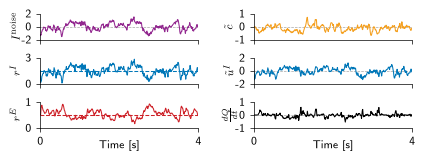

In [8]:
time = np.asarray(ts)
fig = MultiPanel(grid=[2, 2, 2], figsize=(10.5 * cm, 3.8 * cm), wspace=0.1, hspace=0.0)
plt.gcf().set_size_inches(10.5 * cm, 3.8 * cm, forward=True)  # MultiPanel rounds figsize

for idx, (ax, (values, quiet, ylabel, color, ylim, yticks)) in enumerate(zip(fig.panels, trace_panels)):
    ax.plot(time, np.asarray(values), color=color, lw=linewidth, rasterized=True)
    if quiet is not None:
        ax.plot(time, np.asarray(quiet), color=color, lw=linewidth, ls='--', rasterized=True)
    if idx in (0, 1, 3, 5):
        ax.axhline(0, color='0.65', lw=0.5, ls='--', zorder=-2)
    ax.set_ylabel(ylabel, ha='center', va='center')
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{t:g}' for t in yticks])
    ax.set_xlim(0, 4)
    ax.set_xticks([0, 4])
    if idx < 4:
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.set_xticklabels(['0', '4'])
        ax.set_xlabel('Time [s]', labelpad=-5)
plt.gcf().align_ylabels([fig.panels[i] for i in (0, 2, 4)])

plt.savefig(fig7_dir / 'b-c_offline_phase.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Panels e-f: feedback pre-training with fixed feed-forward weights

$A_l$ is the subspace alignment of layer $l$'s feedback with the Jacobian row space, $C_l$ (dashed) the ceiling attainable by sample-independent feedback. The gray band in f is $A_l/C_l$ of the untrained random-feedback networks (layer mean, mean $\pm$ SD over seeds).

In [9]:
pretrain_epochs = np.array([record['epoch'] for record in st['learned'][0].results['pretrain_fb']])


def pretrain_field(runs, field, layer):
    return np.array([[record[field][layer] for record in run.results['pretrain_fb']] for run in runs])


def initial_random_ratio(run):
    # alignment / ceiling of the random feedback before the first training batch
    seeds, dataset, model, trainer = build(run)
    state = trainer.get_initial_train_state(dataset, seeds['init_key'])
    batch = tuple(np.asarray(v).copy() for v in next(iter(dataset.get_train_data(int(run.config.batchsize), flatten=model.vf.flatten_input))))
    alignment = np.asarray(trainer.fb_subspace_alignment(state, batch))
    ceiling = np.asarray(trainer.fb_subspace_alignment_ceiling(state, batch))
    return (alignment / ceiling).mean()


random_ratio = np.array([initial_random_ratio(run) for run in st['random']])
print(f'untrained random feedback, A/C: {random_ratio.mean():.3f} +- {random_ratio.std():.3f}')

untrained random feedback, A/C: 0.555 +- 0.024


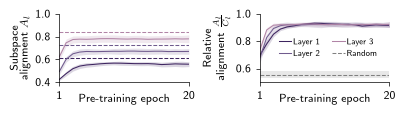

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10 * cm, 2.6 * cm), sharex=True, layout='constrained')

for layer, color in enumerate(layer_colors):
    mean_std(axes[0], pretrain_epochs, pretrain_field(st['learned'], 'alignment', layer), color, label=rf'Layer {layer + 1}')
    axes[0].plot(pretrain_epochs, pretrain_field(st['learned'], 'ceiling', layer).mean(0), color=color, lw=linewidth, ls='--')
    mean_std(axes[1], pretrain_epochs, pretrain_field(st['learned'], 'ratio', layer), color, label=rf'Layer {layer + 1}')

axes[1].axhspan(random_ratio.mean() - random_ratio.std(), random_ratio.mean() + random_ratio.std(),
                color='gray', alpha=0.18, lw=0, zorder=-2)
axes[1].axhline(random_ratio.mean(), color='gray', lw=linewidth, ls='--', label='Random')

axes[0].set_ylabel('Subspace\nalignment' + r' $A_l$')
axes[1].set_ylabel('Relative\nalignment' + r' $\frac{A_l}{C_l}$')
axes[0].set_ylim(0.4, 1.0)
axes[1].set_ylim(0.5, 1.0)
for ax in axes:
    ax.set_xlim(1, 20)
    ax.set_xticks([1, 20])
    ax.set_xlabel('Pre-training epoch', labelpad=-5)
axes[1].legend(frameon=False, fontsize=6, ncol=2, loc='center right', handletextpad=0.2, columnspacing=1.5,
               handlelength=1.5, borderpad=1)

for ax in axes:
    text_ticks(ax)

plt.savefig(fig7_dir / 'e-f_pretraining_alignment.pdf')
plt.show()

### Panels g-i: interleaved feed-forward and feedback training

Open-loop training loss, hidden-layer mean subspace alignment $A_l$, and the angle between the applied feed-forward update and the update with analytic feedback (mean over the three hidden blocks and the readout).

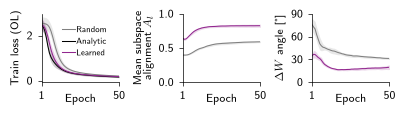

In [11]:
joint_epochs = np.arange(1, stack(st['learned'], 'train_OL_loss').shape[1] + 1)


def ff_update_angle(runs):
    blocks = [f'L{layer}' for layer in range(int(runs[0].config.model.vf.nb_hidden))] + ['readout']
    return np.mean([stack(runs, f'train_CL_fb_ffangle_{block}') for block in blocks], axis=0)


fig, axes = plt.subplots(1, 3, figsize=(10 * cm, 2.6 * cm), layout='constrained')

for condition in ['random', 'analytic', 'learned']:
    mean_std(axes[0], joint_epochs, stack(st[condition], 'train_OL_loss'), condition_colors[condition], label=condition.capitalize())
for condition in ['random', 'learned']:
    mean_std(axes[1], joint_epochs, stack(st[condition], 'train_CL_fb_subalign_mean'), condition_colors[condition])
    mean_std(axes[2], joint_epochs, ff_update_angle(st[condition]), condition_colors[condition])

axes[0].set_ylabel('Train loss (OL)')
axes[0].legend(frameon=False, fontsize=6, loc='upper right', handletextpad=0.2, handlelength=1.5, borderpad=1)
axes[1].set_ylabel('Mean subspace\nalignment' + r' $A_l$')
axes[1].set_ylim(0, 1)
axes[2].set_ylabel(r'Mean $\vartheta_l$ [°]')
axes[2].set_ylim(0, 90)
axes[2].set_yticks([0, 30, 60, 90])
for ax in axes:
    ax.margins(x=0)
    ax.set_xlim(1, 50)
    ax.set_xticks([1, 50])
    ax.set_xlabel('Epoch', labelpad=-5)

for ax in axes:
    text_ticks(ax)

plt.savefig(fig7_dir / 'g-i_joint_training.pdf')
plt.show()

### Panels k-m: offline-phase frequency

Feedback is updated after every $N_Q$ feed-forward batches, $f_\mathrm{offline} = 1/N_Q$. Panel m shows the final hidden-layer mean $A_l$; the dashed line is the final alignment of fixed random feedback.

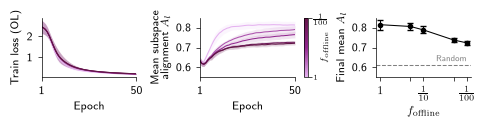

In [12]:
# sequential map derived from color_noise: low frequencies lighter, high frequencies darker
noise_hsv = mpl.colors.rgb_to_hsv(np.asarray(mpl.colors.to_rgb(color_noise)))
frequency_cmap = mpl.colors.LinearSegmentedColormap.from_list('frequency', [
    mpl.colors.hsv_to_rgb([(noise_hsv[0] - 0.035) % 1.0, 0.35 * noise_hsv[1], 0.94]),
    mpl.colors.to_rgb(color_noise),
    mpl.colors.hsv_to_rgb([(noise_hsv[0] + 0.055) % 1.0, min(1.0, 1.08 * noise_hsv[1]), 0.38]),
])
frequency_norm = mpl.colors.LogNorm(vmin=min(frequencies), vmax=max(frequencies))
random_final_alignment = stack(st['random'], 'train_CL_fb_subalign_mean')[:, -1]

fig, axes = plt.subplots(1, 3, figsize=(12 * cm, 2.8 * cm), layout='constrained')

final_alignment = []
for frequency in frequencies:
    runs, color = frequency_runs[frequency], frequency_cmap(frequency_norm(frequency))
    loss, alignment = stack(runs, 'train_OL_loss')[:, :50], stack(runs, 'train_CL_fb_subalign_mean')
    mean_std(axes[0], np.arange(1, 51), loss, color, alpha=0.12)
    mean_std(axes[1], np.arange(1, 51), alignment[:, :50], color, alpha=0.12)
    final_alignment.append(alignment[:, -1])
final_alignment = np.array(final_alignment)

axes[0].set_ylabel('Train loss (OL)')
axes[1].set_ylabel('Mean subspace\nalignment' + r' $A_l$')
axes[1].set_ylim(0.55, 0.85)
for ax in axes[:2]:
    ax.margins(x=0)
    ax.set_xlim(1, 50)
    ax.set_xticks([1, 50])
    ax.set_xlabel('Epoch')

colorbar = fig.colorbar(mpl.cm.ScalarMappable(norm=frequency_norm, cmap=frequency_cmap), ax=axes[1],
                        fraction=0.08, pad=0.03, aspect=15)
colorbar.set_label(r'$f_{\mathrm{offline}}$', fontsize=6, labelpad=-5)
colorbar.set_ticks([1, 100])
colorbar.set_ticklabels([r'$1$', r'$\frac{1}{100}$'])
colorbar.ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
colorbar.ax.tick_params(labelsize=5, pad=1)

axes[2].errorbar(frequencies, final_alignment.mean(1), yerr=final_alignment.std(1),
                 color='black', marker='o', ms=3, lw=linewidth, capsize=2)
axes[2].axhline(random_final_alignment.mean(), color='gray', lw=linewidth, ls='--', zorder=-2)
axes[2].text(frequencies[-1], random_final_alignment.mean() + 0.01, 'Random', color='gray', fontsize=6, ha='right', va='bottom')
axes[2].set_xscale('log')
axes[2].set_xticks([1, 5, 10, 50, 100])
axes[2].set_xticklabels([r'$1$', '', r'$\frac{1}{10}$', '', r'$\frac{1}{100}$'])
axes[2].xaxis.set_minor_locator(mpl.ticker.NullLocator())
axes[2].set_xlabel(r'$f_{\mathrm{offline}}$')
axes[2].set_ylabel(r'Final mean $A_l$')
axes[2].set_ylim(0.55, 0.85)
for ax in axes[:2]:
    text_ticks(ax)
text_ticks(axes[2], 'y')   # the f_offline axis keeps its fraction labels

plt.savefig(fig7_dir / 'k-m_offline_frequency.pdf', bbox_inches='tight')
plt.show()

### Panels n-q: Fashion-MNIST

Analytic feedback and backprop are the Figure 6 three-layer runs. Panel n shows the open-loop training loss; loss values above 1 (diverging epochs of random feedback) are excluded from the mean. Panel q: test accuracy at the epoch of lowest validation loss.

In [13]:
def masked_mean_std(values, threshold=None):
    if threshold is not None:
        values = np.where(values > threshold, np.nan, values)
    with warnings.catch_warnings():  # epochs where every seed is masked give NaN
        warnings.simplefilter('ignore', RuntimeWarning)
        return np.nanmean(values, 0), np.nanstd(values, 0)


curves = {
    # name: (training loss, validation accuracy, color, legend label)
    'analytic': (stack(fmnist['analytic'], 'train_OL_loss'), stack(fmnist['analytic'], 'valid_accuracy'), condition_colors['analytic'], 'Analytic FB'),
    'learned': (stack(fmnist['learned'], 'train_OL_loss'), stack(fmnist['learned'], 'valid_accuracy'), condition_colors['learned'], 'Learned FB'),
    'random': (stack(fmnist['random'], 'train_OL_loss'), stack(fmnist['random'], 'valid_accuracy'), condition_colors['random'], 'Random FB'),
}
test_acc = {name: best_test_accuracy(fmnist[name]) for name in ['analytic', 'learned', 'pretrained']}
references = [(best_test_accuracy(fmnist['backprop']).mean(), 'Backprop')]
if fmnist['nohl']:
    references.append((best_test_accuracy(fmnist['nohl']).mean(), 'No HL'))

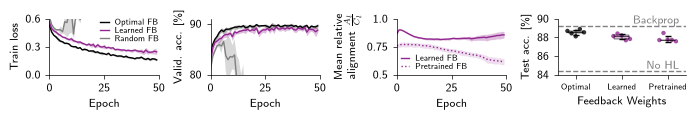

In [16]:
fig = MultiPanel(grid=[4], figsize=(doublecolwidth, 2.6 * cm), hspace=0.0, wspace=0.0, width_ratios=[3, 3, 3, 3.5])
lw = 1.0

for name, (loss, acc, color, label) in curves.items():
    epochs = np.arange(loss.shape[1])
    loss_mean, loss_std = masked_mean_std(loss, threshold=1.0)
    fig.panels[0].plot(epochs, loss_mean, color=color, lw=lw, label=label)
    fig.panels[0].fill_between(epochs, loss_mean - loss_std, loss_mean + loss_std, color=color, alpha=0.3, lw=0)
    fig.panels[1].plot(epochs, acc.mean(0), color=color, lw=lw)
    fig.panels[1].fill_between(epochs, acc.mean(0) - acc.std(0), acc.mean(0) + acc.std(0), color=color, alpha=0.3, lw=0)

for name, ls, alpha, label in [('learned', '-', 0.3, 'Learned FB'), ('pretrained', 'dotted', 0.15, 'Pretrained FB')]:
    ratio = stack(fmnist[name], 'train_CL_fb_subalign_ratio_mean')
    epochs = np.arange(ratio.shape[1])
    fig.panels[2].plot(epochs, ratio.mean(0), color=color_noise, lw=lw, ls=ls, label=label)
    fig.panels[2].fill_between(epochs, ratio.mean(0) - ratio.std(0), ratio.mean(0) + ratio.std(0), color=color_noise, alpha=alpha, lw=0)

fig.panels[0].set_ylabel('Train loss')
fig.panels[0].set_ylim(0, 0.6)
fig.panels[0].set_yticks([0.0, 0.3, 0.6])
fig.panels[0].set_yticklabels(['0.0', '0.3', '0.6'])
fig.panels[0].legend(loc='upper right', frameon=False, fontsize=6, handlelength=1, handletextpad=0.7, borderpad=-0.5, labelspacing=0.1)
fig.panels[1].set_ylabel(r'Valid. acc. [\%]')
fig.panels[1].set_ylim(80, 91)
fig.panels[1].set_yticks([80, 90])
fig.panels[1].set_yticklabels(['80', '90'])
fig.panels[2].set_ylabel('Mean relative\nalignment ' + r'$\frac{A_l}{C_l}$')
fig.panels[2].set_ylim(0.5, 1.0)
fig.panels[2].set_yticks([0.5, 0.75, 1.0])
fig.panels[2].set_yticklabels(['0.5', '0.75', '1.0'])
fig.panels[2].legend(loc='lower left', frameon=False, fontsize=6, handlelength=1, handletextpad=0.7, borderpad=0.0, labelspacing=0.1)
for ax in fig.panels[:3]:
    ax.set_xlabel('Epoch')
    ax.set_xlim(0, 50)
    ax.set_xticks([0, 25, 50])
    ax.set_xticklabels(['0', '25', '50'])

# panel q: test accuracy per network, box + points
ax = fig.panels[3]
positions = [0.9, 2.7, 4.5]
for pos, name, color in zip(positions, ['analytic', 'learned', 'pretrained'], [condition_colors['analytic'], color_noise, color_noise]):
    data = test_acc[name]
    ax.boxplot([data], positions=[pos], widths=0.6, patch_artist=True, showfliers=False, showcaps=False,
               boxprops=dict(facecolor=to_rgba(color, 0.3), edgecolor='black', linewidth=0.35),
               whiskerprops=dict(linewidth=0.35, color='black'), medianprops=dict(linewidth=0.45, color='black'))
    ax.scatter(np.linspace(pos - 0.325, pos + 0.325, len(data)), data, s=10, color=color, alpha=0.8, edgecolors='none')
    ax.errorbar(pos, data.mean(), yerr=data.std(), fmt='none', ecolor='black', capsize=2, linewidth=0.3)
for value, label in references:
    ax.axhline(value, color='gray', ls='--', lw=lw)
    ax.annotate(label, xy=(4.95, value), color='gray', ha='right', va='bottom', fontsize=8)
ax.set_xticks(positions)
ax.set_xticklabels(['Analytic', 'Learned', 'Pretrained'], fontsize=6)
ax.set_xlim(0.2, 5.2)
ax.set_ylim(84, 90)
ax.set_yticks([84, 86, 88, 90])
ax.set_yticklabels(['84', '86', '88', '90'])
ax.set_ylabel(r'Test acc. [\%]')
ax.set_xlabel('Feedback Weights')

plt.savefig(fig7_dir / 'n-q_fmnist.pdf', dpi=300, bbox_inches='tight')
plt.show()